## Simplest BaseLine Model..

This notebook runs the Simple Moving Average (SAM) model which is the simplest baseline..

In [2]:
import all_imports as ai

In [ ]:
data = ai.pd.read_csv("data")
col_name = "CO"
dit = data[[col_name]]

In [ ]:
#NO, CO, PM-10.   this are the vairables we will be working with...

Data loaded successfully!
Data shape: (26304, 1)
Date range: 2020-01-01 00:00:00 to 2022-12-31 23:00:00
Total observations: 26304
Training set: 21043 observations
Test set: 5261 observations

SIMPLE MOVING AVERAGE FORECAST EVALUATION

24-hour Forecast:
MAE: 4.3680
RMSE: 5.1858
MAPE: 42.17%

48-hour Forecast:
MAE: 3.8167
RMSE: 4.5509
MAPE: 33.39%


C:\Users\Lawrence Swen Tuah\AppData\Local\Temp\ipykernel_13952\1716802296.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates_24 = pd.date_range(start=test.index[0], periods=horizon_24, freq='H')
C:\Users\Lawrence Swen Tuah\AppData\Local\Temp\ipykernel_13952\1716802296.py:124: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates_50 = pd.date_range(start=test.index[0], periods=horizon_50, freq='H')


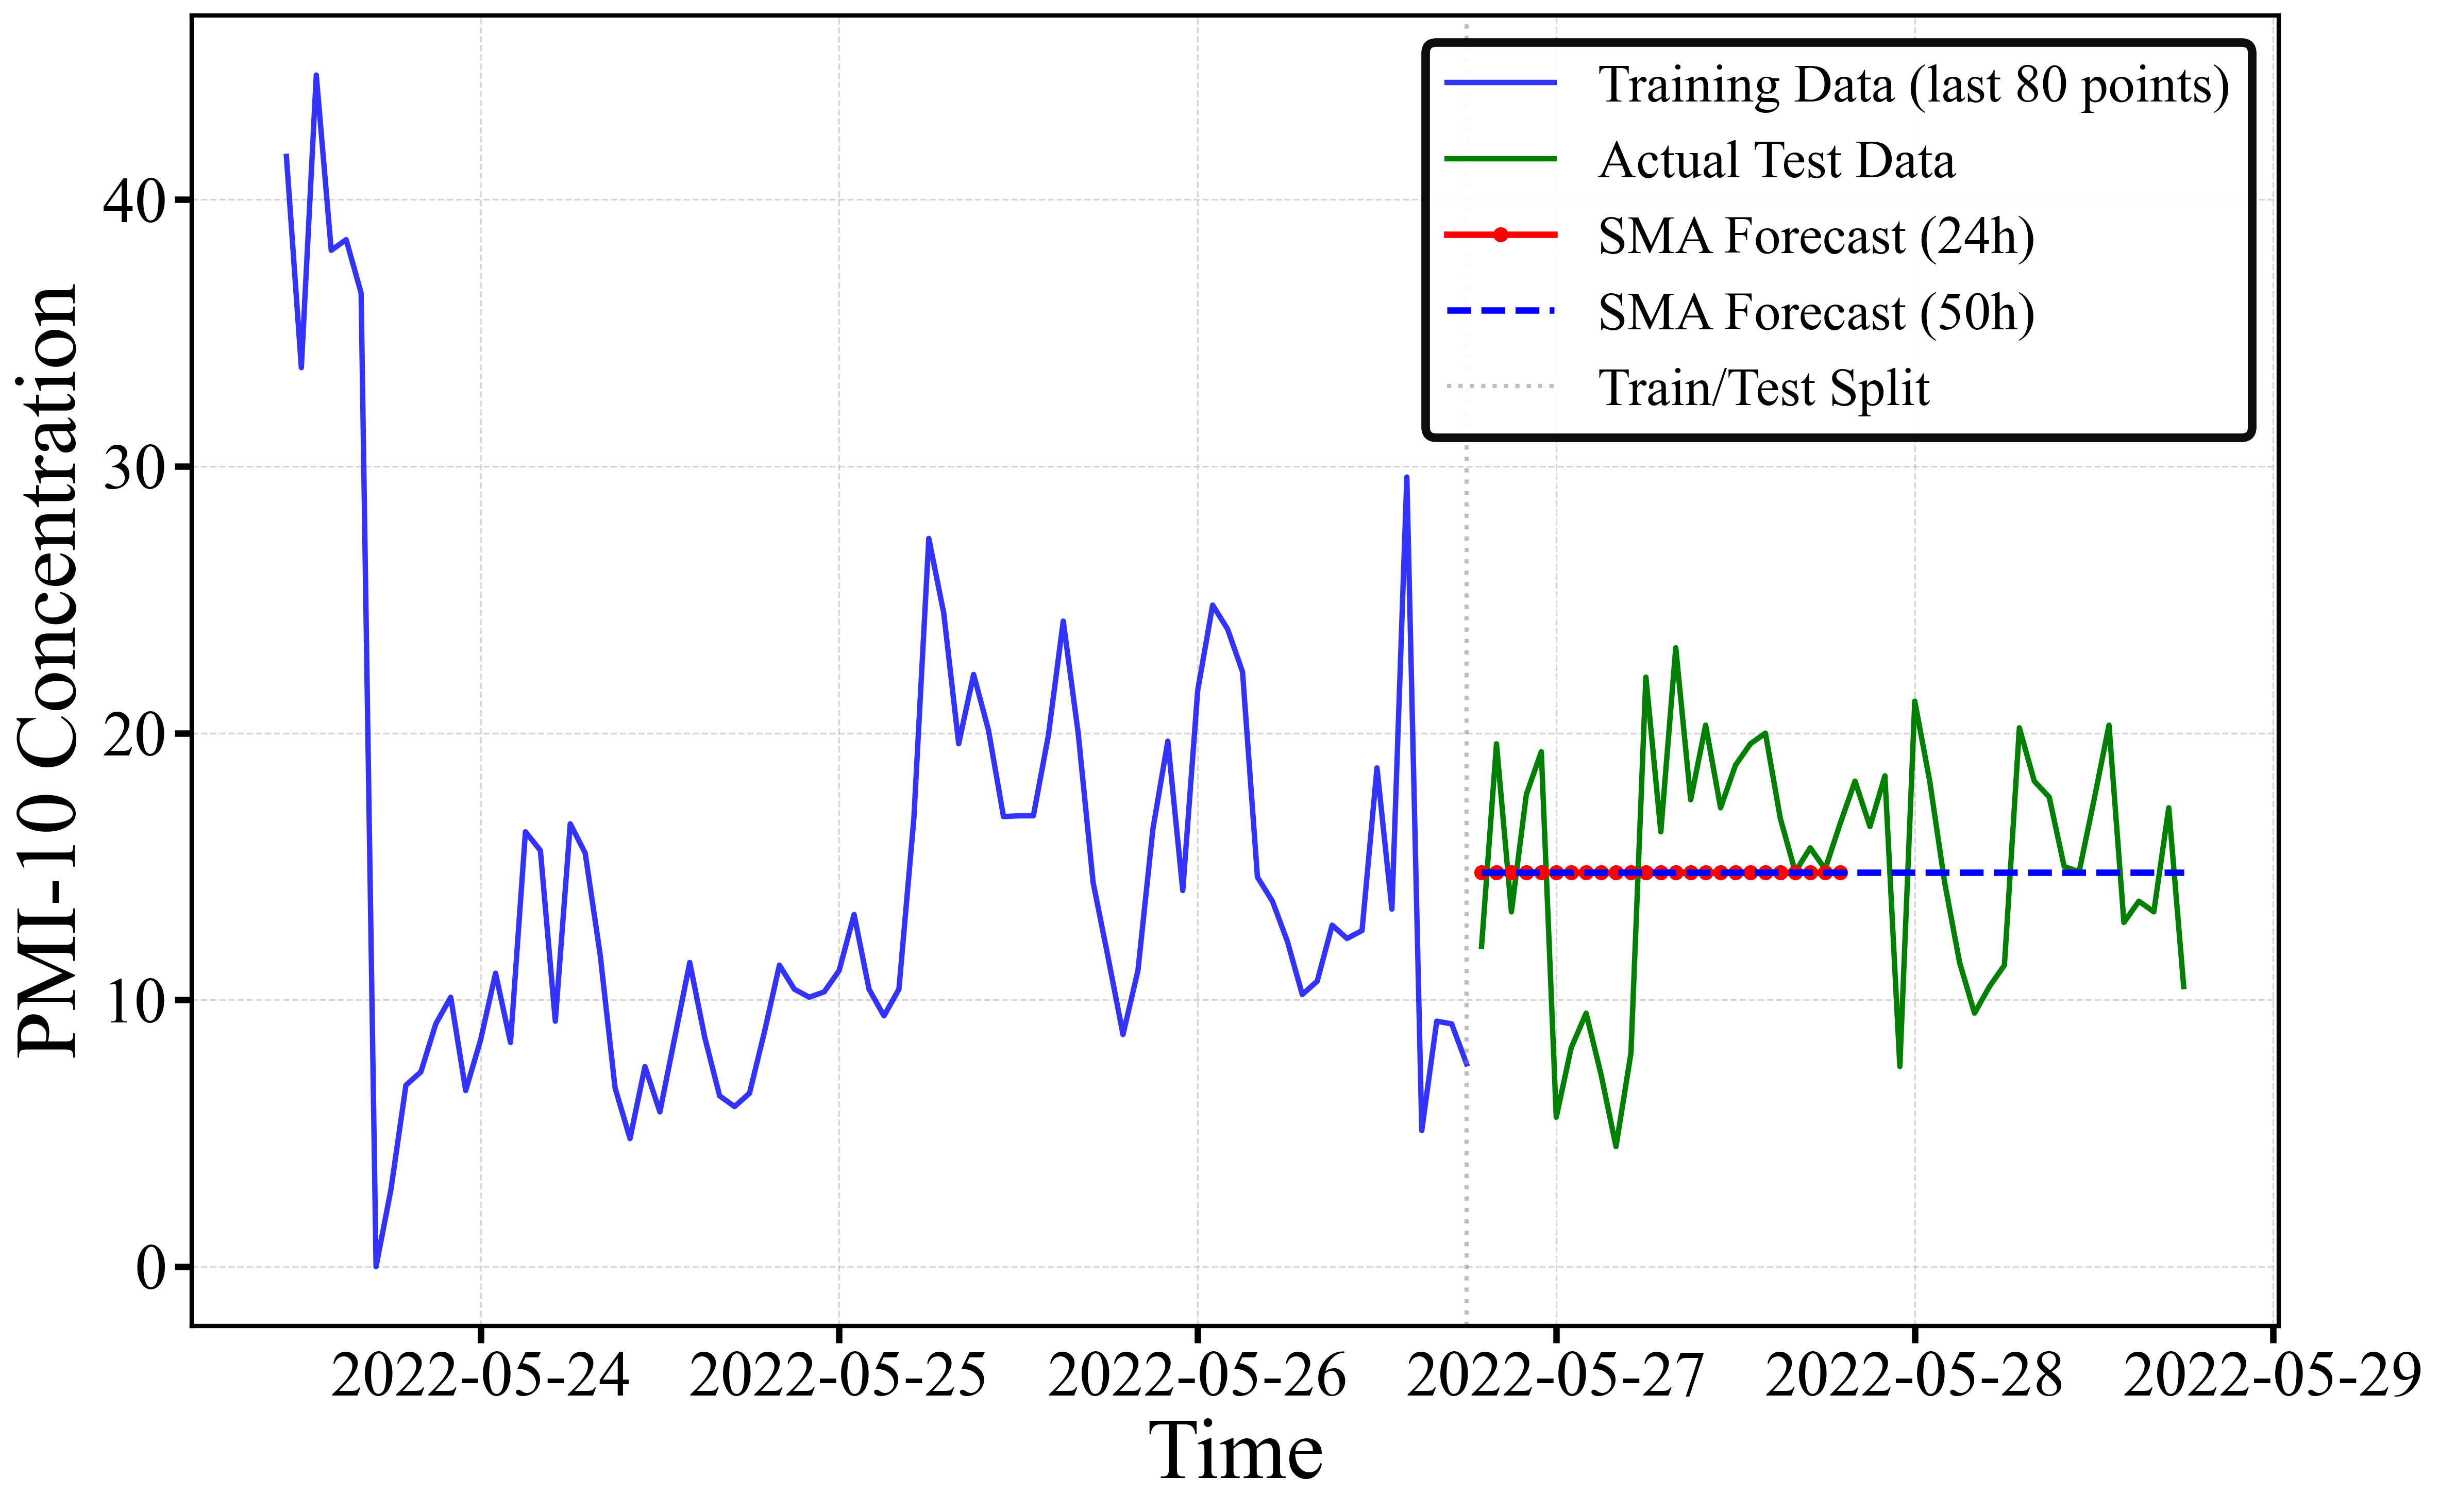

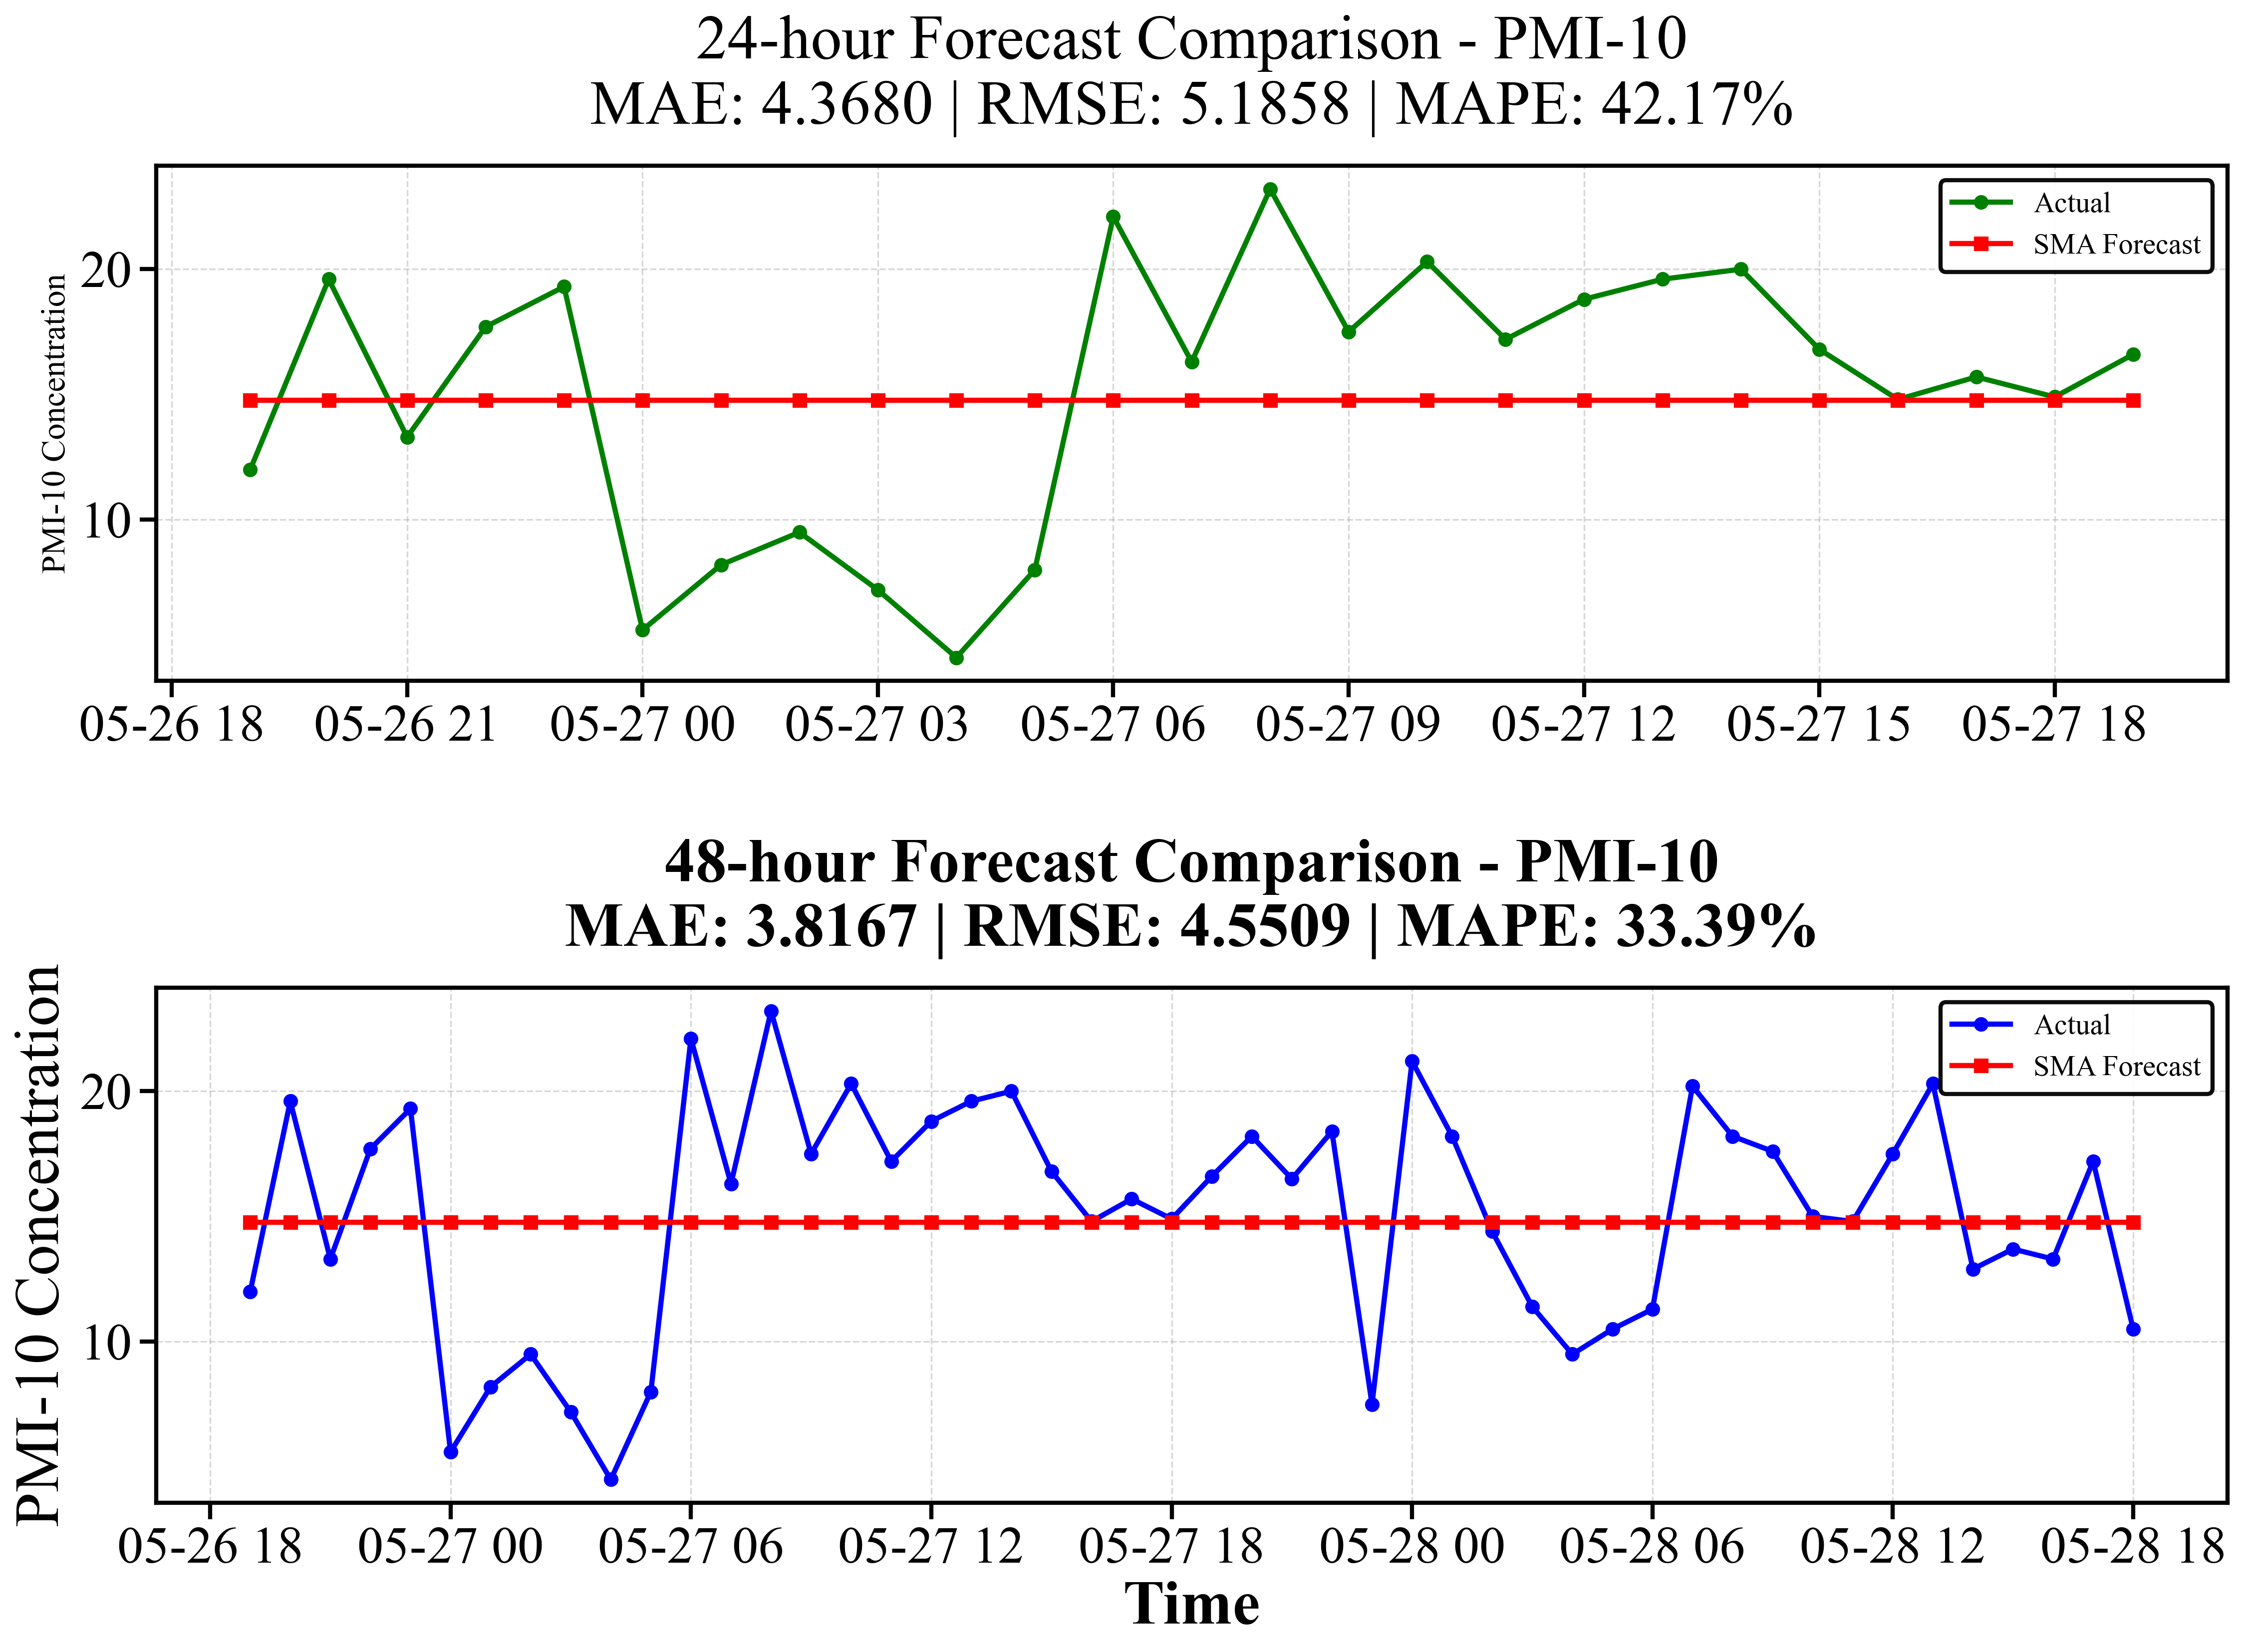


FORECAST SUMMARY:
24-hour forecast: 14.7667 (constant)
48-hour forecast: 14.7667 (constant)
Based on last 24 training observations average: 14.7667


In [ ]:

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    return ai.np.mean(ai.np.abs((y_true - y_pred) / y_true)) * 100

def split_series(series, train_size):
    """Split series into train and test sets"""
    train_size = int(len(series) * train_size)
    train = series[:train_size]
    test = series[train_size:]
    return train, test

def simple_moving_average_forecast(train_data, window_size, horizon):
    """Generate Simple Moving Average forecast"""
    # Use the average of the last window_size observations
    forecast_value = train_data[-window_size:].mean()
    return ai.np.full(horizon, forecast_value)

def evaluate_forecast(actual, predicted):
    """Evaluate forecast performance"""
    mae = ai.mean_absolute_error(actual, predicted)
    rmse = ai.np.sqrt(ai.mean_squared_error(actual, predicted))
    mape = ai.mean_absolute_percentage_error(actual, predicted)
    return mae, rmse, mape

# =============================================================================
# LOAD AND PREPARE DATA (Keep exactly as is)
# =============================================================================
data = ai.pd.read_csv("data")
col_name = "PMI-10"   # the pollutant name
series = data[[col_name]]

# Convert index to datetime if needed
series.index = ai.pd.to_datetime(series.index)

print(f"Data loaded successfully!")
print(f"Data shape: {series.shape}")
print(f"Date range: {series.index.min()} to {series.index.max()}")
print(f"Total observations: {len(series)}")

# Split the data
train_size = 0.8
train, test = split_series(series, train_size)

print(f"Training set: {len(train)} observations")
print(f"Test set: {len(test)} observations")

# Set parameters
window_size = 24  # You can try 12, 48, etc.
horizon_24 = 25
horizon_50 = 48

# Generate forecasts
sma_forecast_24 = simple_moving_average_forecast(train, window_size, horizon_24)
sma_forecast_50 = simple_moving_average_forecast(train, window_size, horizon_50)

# Create future dates for plotting
future_dates_24 = ai.pd.date_range(start=test.index[0], periods=horizon_24, freq='H')
future_dates_50 = ai.pd.date_range(start=test.index[0], periods=horizon_50, freq='H')

# Evaluate forecasts
mae_24, rmse_24, mape_24 = evaluate_forecast(test[:horizon_24].values.flatten(), sma_forecast_24)
mae_50, rmse_50, mape_50 = evaluate_forecast(test[:horizon_50].values.flatten(), sma_forecast_50)

# Print results
print("\n" + "="*60)
print("SIMPLE MOVING AVERAGE FORECAST EVALUATION")
print("="*60)
print(f"\n24-hour Forecast:")
print(f"MAE: {mae_24:.4f}")
print(f"RMSE: {rmse_24:.4f}")
print(f"MAPE: {mape_24:.2f}%")

print(f"\n48-hour Forecast:")
print(f"MAE: {mae_50:.4f}")
print(f"RMSE: {rmse_50:.4f}")
print(f"MAPE: {mape_50:.2f}%")

# =============================================================================
# PLOT 1: COMBINED VIEW
# =============================================================================
fig1, ax1 = ai.plt.subplots(figsize=(16, 10))

# Plot last part of training data and forecasts
plot_train_points = min(80, len(train))
ax1.plot(train[-plot_train_points:].index, train[-plot_train_points:].values, 
         label="Training Data (last 80 points)", color='blue', alpha=0.8, linewidth=2.5)

ax1.plot(test[:horizon_50].index, test[:horizon_50].values, 
         label="Actual Test Data", color='green', linewidth=2.5)

# Plot forecasts
ax1.plot(future_dates_24, sma_forecast_24, label=f"SMA Forecast (24h)", 
         color='red', linewidth=3, marker='o', markersize=6)
ax1.plot(future_dates_50, sma_forecast_50, label=f"SMA Forecast (50h)", 
         color='blue', linestyle='--', linewidth=3)

ax1.axvline(x=train.index[-1], color='gray', linestyle=':', alpha=0.5, 
            linewidth=2, label='Train/Test Split')

# ax1.set_title(f"Simple Moving Average Forecast - {col_name}", 
#               fontsize=30, fontweight='bold', pad=25)
ax1.set_xlabel("Time", fontsize=40, fontweight='normal')
ax1.set_ylabel(f"{col_name} Concentration", fontsize=40, fontweight='normal')

# Publication-ready tick and border formatting
ax1.tick_params(axis='both', which='major', labelsize=30, width=3, length=8)
ax1.tick_params(axis='both', which='minor', labelsize=30, width=3, length=6)

# Enhance border visibility
for spine in ax1.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Set legend with custom linewidth (applied individually)
legend = ax1.legend(loc='upper right', framealpha=0.95, fontsize=25, frameon=True, 
                   edgecolor='black', facecolor='white')
legend.get_frame().set_linewidth(4)  # This sets the legend border width

ax1.grid(True, alpha=0.5)

# Format x-axis for better date display
ai.plt.xticks(rotation=0)
ai.plt.tight_layout()
# plt.savefig("results_plot/SMA_plot.pdf", format='pdf', bbox_inches='tight', dpi=600)
ai.plt.show()

# =============================================================================
# PLOT 2: COMPARISON SUBPLOTS
# =============================================================================
fig2, (ax2, ax3) = ai.plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: 24-hour forecast comparison
ax2.plot(test[:horizon_24].index, test[:horizon_24].values, 
         label="Actual", color='green', linewidth=2.5, marker='o', markersize=6)
ax2.plot(future_dates_24, sma_forecast_24, label="SMA Forecast", 
         color='red', linewidth=2.5, marker='s', markersize=6)
ax2.set_title(f"24-hour Forecast Comparison - {col_name}\n"
              f"MAE: {mae_24:.4f} | RMSE: {rmse_24:.4f} | MAPE: {mape_24:.2f}%", 
              fontsize=30, fontweight='normal', pad=20)
ax2.set_ylabel(f"{col_name} Concentration", fontsize=16, fontweight='normal')

# Plot 2: 50-hour forecast comparison
ax3.plot(test[:horizon_50].index, test[:horizon_50].values, 
         label="Actual", color='blue', linewidth=2.5, marker='o', markersize=6)
ax3.plot(future_dates_50, sma_forecast_50, label="SMA Forecast", 
         color='red', linewidth=2.5, marker='s', markersize=6)
ax3.set_title(f"48-hour Forecast Comparison - {col_name}\n"
              f"MAE: {mae_50:.4f} | RMSE: {rmse_50:.4f} | MAPE: {mape_50:.2f}%", 
              fontsize=30, fontweight='bold', pad=20)
ax3.set_xlabel("Time", fontsize=30, fontweight='bold')
ax3.set_ylabel(f"{col_name} Concentration", fontsize=30, fontweight='normal')

# Apply publication-ready formatting to both subplots
for ax in [ax2, ax3]:
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=25, width=2, length=8)
    ax.tick_params(axis='both', which='minor', labelsize=25, width=1.5, length=6)
    
    # Border formatting
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # Legend with custom border width
    legend = ax.legend(fontsize=14, frameon=True, edgecolor='black', 
                      facecolor='white', framealpha=0.95)
    legend.get_frame().set_linewidth(2)
    
    ax.grid(True, alpha=0.5)
    
    # Format x-axis dates
    ai.plt.sca(ax)
    ai.plt.xticks(rotation=0)

ai.plt.tight_layout(pad=3.0)
ai.plt.show()

# =============================================================================
# PRINT SUMMARY (Keep exactly as is)
# =============================================================================
print(f"\nFORECAST SUMMARY:")
print(f"24-hour forecast: {sma_forecast_24[0]:.4f} (constant)")
print(f"48-hour forecast: {sma_forecast_50[0]:.4f} (constant)")
print(f"Based on last {window_size} training observations average: {train[-window_size:].mean().iloc[0]:.4f}")

# Save figures with publication quality
# fig1.savefig('sma_forecast_combined.png', dpi=600, bbox_inches='tight', facecolor='white')
# fig2.savefig('sma_forecast_comparison.png', dpi=600, bbox_inches='tight', facecolor='white')